In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

from network_original_lpn import LPN
from network_ne_by_norm import NE_LPN_By_Norm
from network_ne_by_design import NE_LPN_By_Design
from utils import prox, cvx, prior, gt_cvx, prox_gaussian

sns.set()

MODEL_DIR = "experiments/models/"
PLOT_DIR = "experiments/plots/"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

np.random.seed(1)
torch.manual_seed(1)

In [2]:
class NormalSampler:
    def __init__(self, mean=0.0, std=1.0):
        self.mean = mean
        self.std = std

    def __call__(self, n):
        return torch.randn(n) * self.std + self.mean

def add_noise(x, sigma=0.1):
    return x + torch.randn_like(x) * sigma

def exp_func(x, gamma):
    return -torch.exp(-((x / gamma) ** 2)) + 1

In [3]:
def single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss=None):
    target = sampler(bsize).unsqueeze(1).to(device)
    input_ = add_noise(target, sigma_noise).to(device)
    output = model(input_)

    if loss_type == 2:
        loss = torch.nn.functional.mse_loss(output, target)
    elif loss_type == 1:
        loss = torch.nn.functional.l1_loss(output, target)
    elif loss_type == 0:
        loss = exp_func(output - target, gamma_loss).mean()
    else:
        raise ValueError("Invalid loss_type")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if hasattr(model, "wclip"):
        model.wclip()
    return loss.item()


In [4]:
def plot_all(model, title):
    xi = np.linspace(-4, 4, 1000)
    y = prox(xi, model)
    c = cvx(xi, model)
    p = prior(xi, model)

    fig, axs = plt.subplots(1, 3, figsize=(8, 3))
    axs[0].plot(xi, y, label="LPN")
    axs[0].plot(xi, prox_gaussian(xi), '--', label="soft thr.")
    axs[0].set_title("Learned prox")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(xi, c - c.min(), label="Cvx func")
    axs[1].plot(xi, gt_cvx(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(xi, p - p.min(), label="LPN")
    axs[2].plot(xi, 0.5 * xi**2, '--', label=r"$\frac{1}{2}x^2$")
    axs[2].set_title("Original func")
    axs[2].grid(True)
    axs[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_plot.png"))
    plt.show()

In [5]:
def plot_comparison(models):
    xi = np.linspace(-4, 4, 1000)
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    for name, model in models.items():
        y = prox(xi, model)
        c = cvx(xi, model)
        p = prior(xi, model)

        axs[0].plot(xi, y, label=name)
        axs[1].plot(xi, c - c.min(), label=name)
        axs[2].plot(xi, p - p.min(), label=name)

    axs[0].plot(xi, prox_gaussian(xi), '--', label="gaussian prox")
    axs[0].set_title("Learned prox")
    axs[1].plot(xi, gt_cvx(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[2].plot(xi, 0.5 * xi**2, '--', label=r"$\frac{1}{2}x^2$")
    axs[2].set_title("Original func")

    for ax in axs:
        ax.grid(True)
        ax.legend()

    plt.suptitle("Model Comparison")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "model_comparison.png"))
    plt.show()
    

In [6]:
def train_model(model, model_name, loss_type, gamma_loss, sampler, sigma_noise, 
                lr_schedule, iterations_per_phase):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_schedule[0])
    bsize = 2000
    loss_log = []

    print(f"Training {model_name}...")
    for phase, lr in enumerate(lr_schedule):
        for g in optimizer.param_groups:
            g['lr'] = lr
        for i in range(iterations_per_phase):
            loss = single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss)
            if i % 100 == 0:
                print(f"{model_name} | Phase {phase+1}/{len(lr_schedule)} | Iter {i}: Loss = {loss:.6f}")
                loss_log.append(loss)

    # Save and plot
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    plot_all(model, title=model_name)
    return model
    

In [7]:
sampler = NormalSampler()
sigma_noise = 1.0
loss_type = 0  # Proximal matching loss
gamma_loss = 0.1
lr_schedule = [1e-3, 1e-4]  # mimic original notebook
iterations_per_phase = 10000

In [8]:
dim = 1
hidden = 50
layers = 4
beta = 10

In [9]:
def get_models():
    return {
        "Original_LPN": LPN(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "NE_By_Norm": NE_LPN_By_Norm(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "NE_By_Design": NE_LPN_By_Design(in_dim=dim, hidden=hidden, layers=layers, beta=beta)
    }

Training Original_LPN...
Original_LPN | Phase 1/2 | Iter 0: Loss = 0.937403
Original_LPN | Phase 1/2 | Iter 100: Loss = 0.895834
Original_LPN | Phase 1/2 | Iter 200: Loss = 0.914492
Original_LPN | Phase 1/2 | Iter 300: Loss = 0.906864
Original_LPN | Phase 1/2 | Iter 400: Loss = 0.894702
Original_LPN | Phase 1/2 | Iter 500: Loss = 0.912057
Original_LPN | Phase 1/2 | Iter 600: Loss = 0.897844
Original_LPN | Phase 1/2 | Iter 700: Loss = 0.897855
Original_LPN | Phase 1/2 | Iter 800: Loss = 0.906391
Original_LPN | Phase 1/2 | Iter 900: Loss = 0.903861
Original_LPN | Phase 1/2 | Iter 1000: Loss = 0.902033
Original_LPN | Phase 1/2 | Iter 1100: Loss = 0.903924
Original_LPN | Phase 1/2 | Iter 1200: Loss = 0.904754
Original_LPN | Phase 1/2 | Iter 1300: Loss = 0.905576
Original_LPN | Phase 1/2 | Iter 1400: Loss = 0.901614
Original_LPN | Phase 1/2 | Iter 1500: Loss = 0.902897
Original_LPN | Phase 1/2 | Iter 1600: Loss = 0.903110
Original_LPN | Phase 1/2 | Iter 1700: Loss = 0.899538
Original_LPN | 

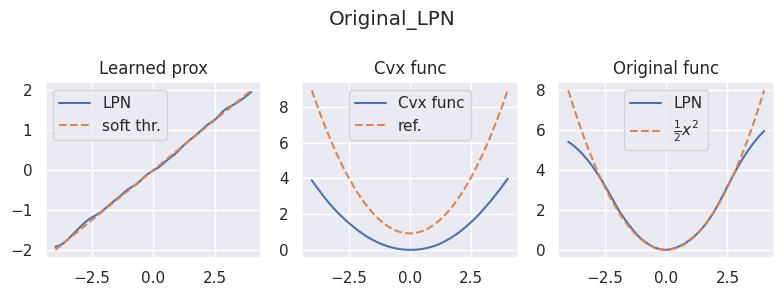

Training NE_By_Norm...
NE_By_Norm | Phase 1/2 | Iter 0: Loss = 0.939033
NE_By_Norm | Phase 1/2 | Iter 100: Loss = 0.918259
NE_By_Norm | Phase 1/2 | Iter 200: Loss = 0.908320
NE_By_Norm | Phase 1/2 | Iter 300: Loss = 0.906404
NE_By_Norm | Phase 1/2 | Iter 400: Loss = 0.902446
NE_By_Norm | Phase 1/2 | Iter 500: Loss = 0.908175
NE_By_Norm | Phase 1/2 | Iter 600: Loss = 0.905041
NE_By_Norm | Phase 1/2 | Iter 700: Loss = 0.898065
NE_By_Norm | Phase 1/2 | Iter 800: Loss = 0.902250
NE_By_Norm | Phase 1/2 | Iter 900: Loss = 0.900017
NE_By_Norm | Phase 1/2 | Iter 1000: Loss = 0.898043
NE_By_Norm | Phase 1/2 | Iter 1100: Loss = 0.897558
NE_By_Norm | Phase 1/2 | Iter 1200: Loss = 0.906799
NE_By_Norm | Phase 1/2 | Iter 1300: Loss = 0.903165
NE_By_Norm | Phase 1/2 | Iter 1400: Loss = 0.897152
NE_By_Norm | Phase 1/2 | Iter 1500: Loss = 0.902353
NE_By_Norm | Phase 1/2 | Iter 1600: Loss = 0.900341
NE_By_Norm | Phase 1/2 | Iter 1700: Loss = 0.897529
NE_By_Norm | Phase 1/2 | Iter 1800: Loss = 0.901210
N

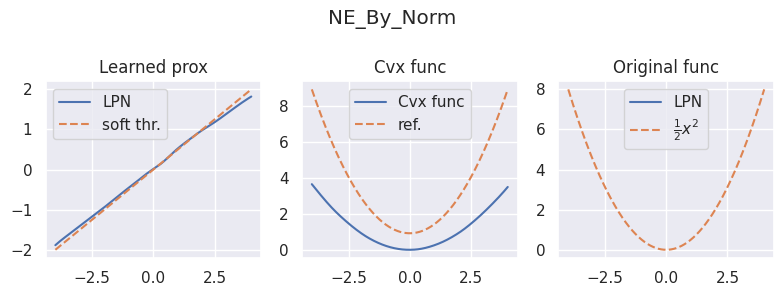

Training NE_By_Design...
NE_By_Design | Phase 1/2 | Iter 0: Loss = 0.936153
NE_By_Design | Phase 1/2 | Iter 100: Loss = 0.956506
NE_By_Design | Phase 1/2 | Iter 200: Loss = 0.907014
NE_By_Design | Phase 1/2 | Iter 300: Loss = 0.916993
NE_By_Design | Phase 1/2 | Iter 400: Loss = 0.897435
NE_By_Design | Phase 1/2 | Iter 500: Loss = 0.910888
NE_By_Design | Phase 1/2 | Iter 600: Loss = 0.904248
NE_By_Design | Phase 1/2 | Iter 700: Loss = 0.902752
NE_By_Design | Phase 1/2 | Iter 800: Loss = 0.909208
NE_By_Design | Phase 1/2 | Iter 900: Loss = 0.908872
NE_By_Design | Phase 1/2 | Iter 1000: Loss = 0.902623
NE_By_Design | Phase 1/2 | Iter 1100: Loss = 0.906682
NE_By_Design | Phase 1/2 | Iter 1200: Loss = 0.905149
NE_By_Design | Phase 1/2 | Iter 1300: Loss = 0.910609
NE_By_Design | Phase 1/2 | Iter 1400: Loss = 0.903693
NE_By_Design | Phase 1/2 | Iter 1500: Loss = 0.910383
NE_By_Design | Phase 1/2 | Iter 1600: Loss = 0.896681
NE_By_Design | Phase 1/2 | Iter 1700: Loss = 0.904030
NE_By_Design | 

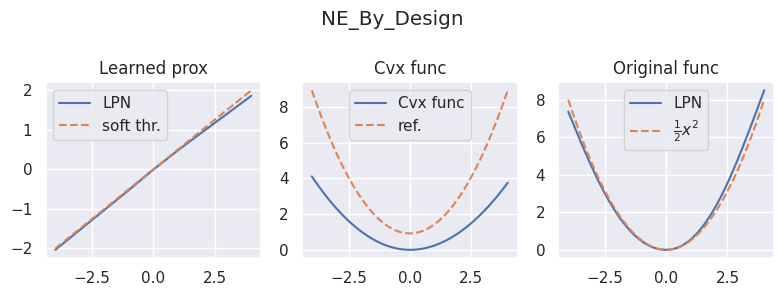

mse 5.344154357910156
mse 3.662184000015259
mse 2.3628990650177
mse 1.633787751197815
mse 1.0500518083572388
mse 0.7703797221183777
mse 0.6547864675521851
mse 0.6242507696151733
mse 0.6130491495132446
mse 0.6074244379997253
final mse 0.6039987802505493
(1000,) (1000,) (1000,) (1000,)
mse nan
mse nan
mse nan
mse nan
mse nan
mse nan
mse nan
mse nan
mse nan
mse nan
final mse nan
(1000,) (1000,) (1000,) (1000,)
mse 5.344064712524414
mse 3.623281478881836
mse 2.4937994480133057
mse 1.694300889968872
mse 1.1300568580627441
mse 0.7386247515678406
mse 0.4723082482814789
mse 0.2949441969394684
mse 0.17955271899700165
mse 0.10636840015649796
final mse 0.061561595648527145
(1000,) (1000,) (1000,) (1000,)


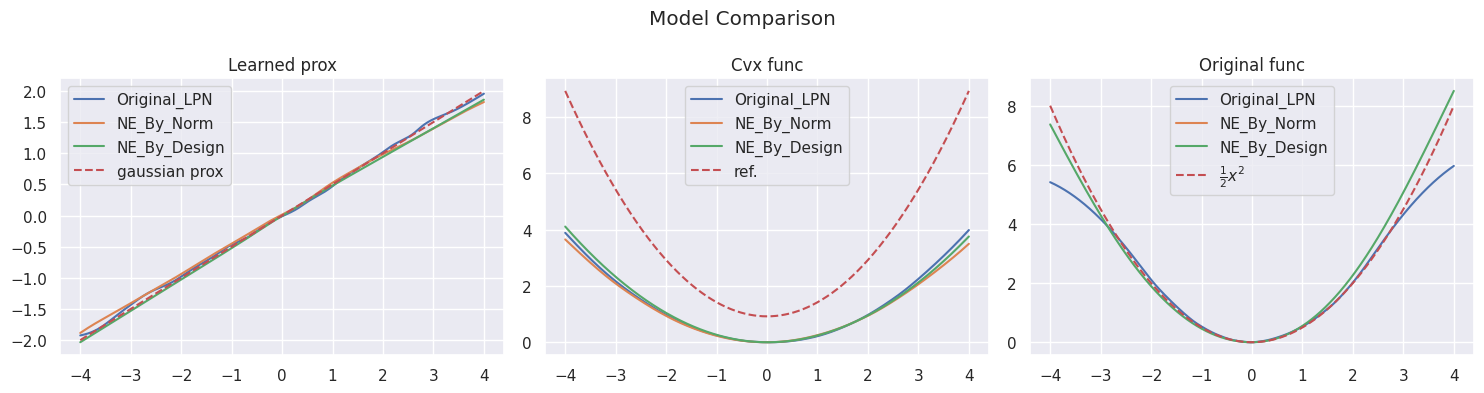

All models trained and plotted.


In [10]:
trained_models = {}
for name, model in get_models().items():
    trained_models[name] = train_model(model, name, loss_type, gamma_loss, 
                                       sampler=sampler, sigma_noise=sigma_noise, 
                                       lr_schedule=lr_schedule, iterations_per_phase=iterations_per_phase)

plot_comparison(trained_models)
print("All models trained and plotted.")